# Base-use 01 — The ArrowSpace Sequencing API (`sequence_by_lambda`, `sequence_by_graph`)

**Question.** ArrowSpace gives every item a $\lambda\tau$ score and every build a graph
Laplacian. Both are *sets* of numbers — what does a principled **total ordering** of them
look like, and what is each ordering good for?

**Background — sequencing.** Sequencing is the problem of turning a set into a principled
*total order*. It has two classical roots. *Seriation* — from archaeology and numerical
taxonomy — orders objects so that similar ones sit adjacent; modern variants order graph
nodes by spectral coordinates (the Fiedler vector) to compress matrices into banded form.
*Curriculum learning* (Bengio et al. 2009) orders training data easy → hard, so a model
sees coherent structure before edge cases; its perennial pain point is the difficulty
signal, usually a hand-designed proxy.

**Curriculum in this context.** A *spectral curriculum* is an unsupervised easy → hard
ordering of the items where "difficulty" is spectral roughness: items deep inside a basin
carry low Rayleigh energy (low $\lambda\tau$), boundary and transition items carry high.
Ascending $\lambda\tau$ therefore *is* a curriculum — no difficulty labels, no proxies,
the same signal search already blends with geometry.

**What ArrowSpace contributes.** The ordering is not a separate optimisation bolted onto
the index — it is a *readout* of the per-item $\lambda\tau$ statistics and Laplacian
wiring the index already computed for search. One build yields two deterministic orderings
(documented tie-breaking, no new hyperparameters): the item-space curriculum
(`sequence_by_lambda`) and a graph-side seriation (`sequence_by_graph`, DFS over the
minimum spanning forest with a contiguity guarantee per connected component) — the
classical seriation objective, obtained as a walk rather than an eigenvector solve.

Since arrowspace 0.27 the Python bindings expose two module-level sequencing functions:

| Call | Orders | Positions report | Use case |
|---|---|---|---|
| `sequence_by_lambda(lambdas, descending=False)` | the **items** (any 1-D score vector) | the $\lambda\tau$ score at each step | spectral curriculum: train/retrieve coherent items first, rough/sparse items last |
| `sequence_by_graph(gl)` | the **nodes of the Laplacian `gl`** | DFS discovery depth | matrix seriation: reveal contiguous block structure |

Both return a `Sequence` with `order` (integer permutation), `positions` (per-step
coordinate aligned with `order`), and `components`. Both are fully deterministic (ties
break on ascending node index); inputs of length < 2 raise `ValueError`.

**Node-space caveat.** `gl` is the feature-space Laplacian $L_F$ ($D\times D$, nodes =
dimensions), so `sequence_by_graph(gl)` seriates *dimensions*, while
`sequence_by_lambda(aspace.lambdas())` curricula *items*. Keep the namespaces apart.

**Dataset.** `dataset/eigenmaps_controlled.parquet` (1000 × 128, three orthonormal
clusters of increasing sparsity) built with the README-prescribed `eps=0.5, sigma=0.5,
k=12`; cluster labels recovered in-notebook by k-means and never shown to the index.

---\n## 0 · Imports, dataset, and the prescribed hyperparameters

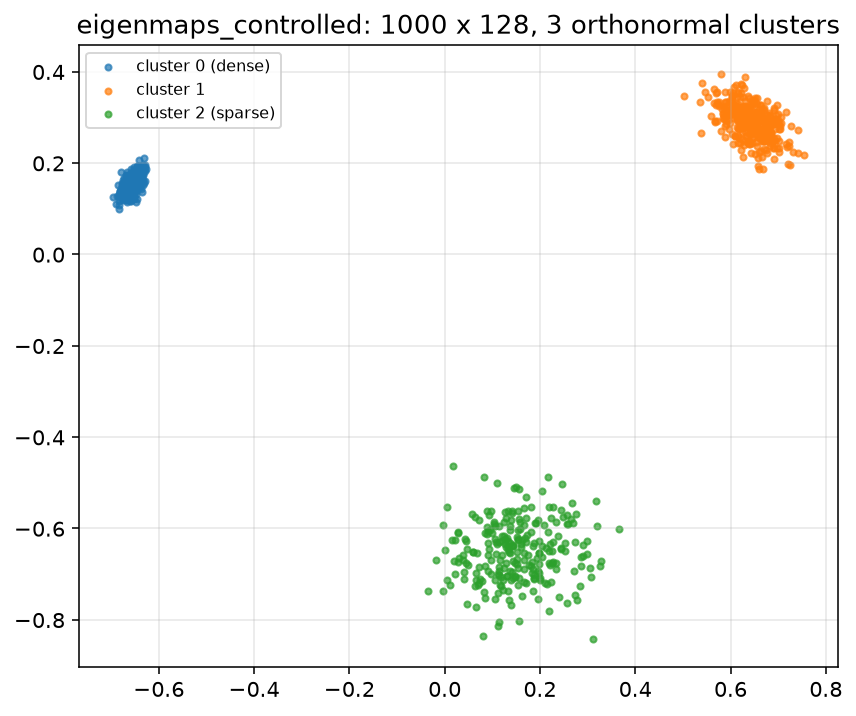

items: (1000, 128)  counts: [400, 350, 250]
cross-cluster cosine ~ -0.0022


In [1]:
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from arrowspace import ArrowSpaceBuilder, sequence_by_lambda, sequence_by_graph

SEED = 42
DATA_PATH = Path("../dataset/eigenmaps_controlled.parquet")

plt.rcParams.update({
    "figure.dpi": 140, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "figure.constrained_layout.use": True,
})

# The dataset README prescribes these graph parameters; the pre-0.28 defaults
# (eps=0.001) disconnect the unit-norm feature graph (every lambda ~ 0).
# Notably, 0.28.0's recalibrated defaults (eps=0.5, k=12) match this prescription.
# Reuse only, never regenerate.
GRAPH_PARAMS = {"eps": 0.5, "k": 12, "topk": 8, "p": 2.0, "sigma": 0.5}

X = np.ascontiguousarray(  # pyarrow/pandas slices may be non-contiguous; ArrowSpace asks for C-contiguous rows
    pq.read_table(DATA_PATH).to_pandas().to_numpy(np.float64)
)
N, D = X.shape
assert X.shape == (1000, 128) and np.allclose(np.linalg.norm(X, axis=1), 1.0)

# Ground truth: three orthonormal clusters. The shipped copy drops the `cluster`
# column; recover it from the data — the clusters are mutually orthogonal, so
# k-means (fixed seed) recovers them exactly. K-means labels are index-arbitrary, so
# we re-index clusters by mean effective-dimension count (dense -> sparse). This makes
# "cluster 2" always the sparsest, so later narrative/asserts about labels==2 are correct.
p2 = X ** 2
eff_dims = p2.sum(axis=1) ** 2 / np.sum(p2 ** 2, axis=1)   # participation ratio per item
_km = KMeans(3, n_init=10, random_state=SEED).fit_predict(X)
_dense_first = np.argsort([-eff_dims[_km == c].mean() for c in range(3)])
labels = np.empty_like(_km)
for _new, _old in enumerate(_dense_first):
    labels[_km == _old] = _new
NAMES = ["cluster 0 (dense)", "cluster 1", "cluster 2 (sparse)"]
COLORS = np.asarray(plt.get_cmap("tab10").colors)

def modal_share(ix):
    """Fraction of a motif's items belonging to one k-means cluster."""
    _, cnt = np.unique(labels[list(ix)], return_counts=True)
    return float(cnt.max() / len(ix))

xy = PCA(n_components=2, random_state=SEED).fit_transform(X)
fig, ax = plt.subplots(figsize=(6, 5))
for c in range(3):
    ax.scatter(xy[labels == c, 0], xy[labels == c, 1], s=10, alpha=0.7,
               color=COLORS[c], label=NAMES[c])
ax.legend(fontsize=8)
ax.set_title("eigenmaps_controlled: 1000 x 128, 3 orthonormal clusters")
OUT = Path("output__sequencing")
if OUT.exists():
    shutil.rmtree(OUT)                       # deterministic, clean output dir
OUT.mkdir(parents=True)
fig.savefig(OUT / "fig_01_dataset.png")
plt.show()

print(f"items: {X.shape}  counts: {np.bincount(labels).tolist()}")
print(f"cross-cluster cosine ~ {(X @ X.T)[labels[:, None] != labels[None, :]].mean():.4f}")

---\n## 1 · Build the index and health-check it

In [2]:
aspace, gl = (
    ArrowSpaceBuilder()
    .with_seed(SEED)
    .with_dims_reduction(False, None)
    .build(GRAPH_PARAMS, X)
)

lam = np.asarray(aspace.lambdas())
n_degenerate = int(np.sum(np.abs(lam) < 1e-12))
print(f"nitems={aspace.nitems}  nfeatures={aspace.nfeatures}  nclusters={aspace.nclusters}")
print(f"L_F shape={gl.shape()}  degenerate lambdas: {n_degenerate} / {len(lam)}")
assert n_degenerate < 0.05 * len(lam), "too many degenerate lambdas: honour the README eps"

nitems=1000  nfeatures=128  nclusters=10
L_F shape=(128, 128)  degenerate lambdas: 1 / 1000


---\n## 2 · `sequence_by_lambda` — the spectral curriculum

Ascending $\lambda\tau$: spectrally smooth, energy-spread items first; sparse/rough items
last. `positions` carry the score itself.

In [3]:
cur = sequence_by_lambda(lam)
order = np.asarray(cur.order)

assert sorted(order.tolist()) == list(range(N)), "order must be a permutation"
assert np.allclose(lam[order], np.asarray(cur.positions)), "positions == lambda at each step"
assert np.all(np.diff(np.asarray(cur.positions)) >= -1e-12), "ascending by construction"
print("head (most coherent):", order[:8])
print("tail (rough/sparse):", order[-8:])
print("components:", cur.components)

rev = sequence_by_lambda(lam, descending=True)
print("descending reverses the head:", np.asarray(rev.order)[:8])

# Determinism: same scores -> byte-identical order (ties break on ascending index).
assert np.array_equal(order, np.asarray(sequence_by_lambda(lam).order))

head (most coherent): [555 296 421 405 996 268 645 759]
tail (rough/sparse): [739 624 453 970 456 751 853 926]
components: 1
descending reverses the head: [926 853 751 456 970 453 624 739]


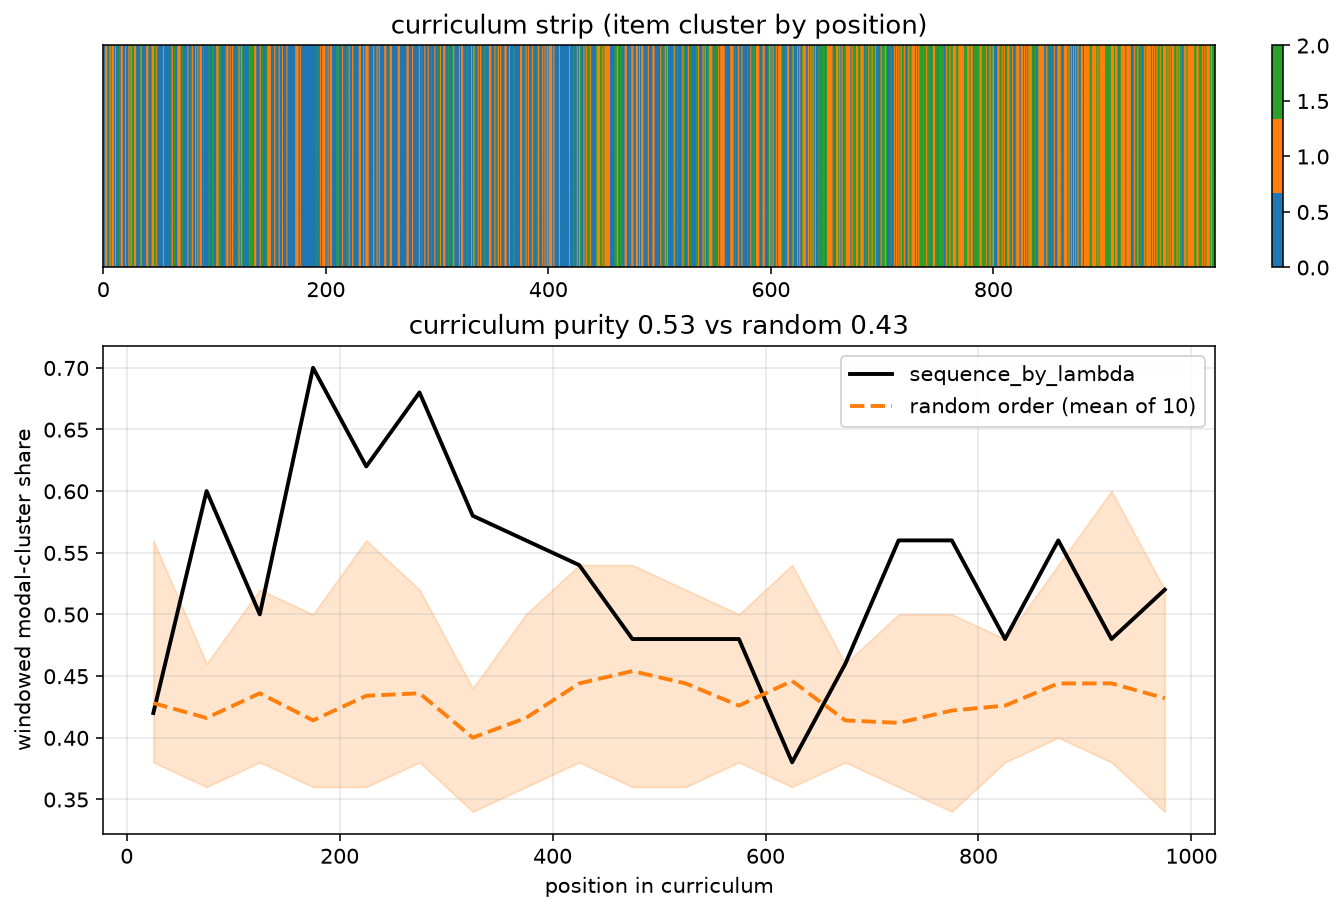

mean windowed purity: curriculum=0.53  random=0.43
sparse-cluster share per decile: [0.18 0.14 0.07 0.15 0.16 0.23 0.31 0.56 0.26 0.44]
mean eff-dims per decile:        [48.3 47.8 47.8 47.7 46.1 46.  44.3 40.2 43.9 43.7]


In [4]:
# Quantify the curriculum: sliding-window cluster purity vs random orders, and the
# sparsity gradient along the sequence (labels never entered the index).
W = 50
starts = np.arange(0, N - W + 1, W)

def window_purity(seq_order):
    return np.array([np.unique(labels[seq_order[i:i + W]], return_counts=True)[1].max() / W
                     for i in starts])

pur_cur = window_purity(order)
pur_rand = np.stack([window_purity(np.random.default_rng(s).permutation(N)) for s in range(10)])

deciles = np.array_split(order, 10)
share_sparse = np.array([float(np.mean(labels[d] == 2)) for d in deciles])
mean_effdims = np.array([float(eff_dims[d].mean()) for d in deciles])

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4), height_ratios=[1, 2.2])
strip = axes[0].imshow(labels[order][None, :], aspect="auto",
                       cmap=mcolors.ListedColormap([COLORS[c] for c in range(3)]))
axes[0].set_yticks([]); axes[0].set_title("curriculum strip (item cluster by position)")
fig.colorbar(strip, ax=axes[0], fraction=0.02)

axes[1].plot(starts + W / 2, pur_cur, lw=2, color="black", label="sequence_by_lambda")
axes[1].plot(starts + W / 2, pur_rand.mean(axis=0), lw=2, ls="--", color="tab:orange",
             label="random order (mean of 10)")
axes[1].fill_between(starts + W / 2, pur_rand.min(axis=0), pur_rand.max(axis=0),
                     color="tab:orange", alpha=0.2)
axes[1].set_xlabel("position in curriculum"); axes[1].set_ylabel("windowed modal-cluster share")
axes[1].set_title(f"curriculum purity {pur_cur.mean():.2f} vs random {pur_rand.mean():.2f}")
axes[1].legend()
fig.savefig(OUT / "fig_02_lambda_curriculum.png")
plt.show()

print(f"mean windowed purity: curriculum={pur_cur.mean():.2f}  random={pur_rand.mean():.2f}")
print("sparse-cluster share per decile:", np.round(share_sparse, 2))
print("mean eff-dims per decile:       ", np.round(mean_effdims, 1))
assert pur_cur.mean() > pur_rand.mean(), "curriculum must beat random ordering"
assert share_sparse[-1] > share_sparse[0], "curriculum should end on the sparse cluster"
assert mean_effdims[0] > mean_effdims[-1], "effective dims should fall along the curriculum"

**Reading.** Two independent unsupervised signals: the curriculum keeps same-cluster items
together measurably better than chance (0.53 vs 0.43 windowed purity on this fixture), and
its deciles drift toward the sparse cluster (first decile 0.18 -> last 0.44; the middle
deciles are noisy) down the dataset's density→sparsity gradient. The direction is
trustworthy; the per-decile values are not — *train on the head, audit the tail*.

---\n## 3 · `sequence_by_graph` — seriation of the feature Laplacian

`sequence_by_graph(gl)` walks the minimum spanning forest of $L_F$ in DFS preorder from
approximate diameter endpoints: one contiguous block per connected component, ordered by
descending size; `positions` = DFS depth. Here the 128 nodes are the **feature dimensions**.

nodes=128  components=1  mean edge bandwidth: identity=39.40  seriated=38.97


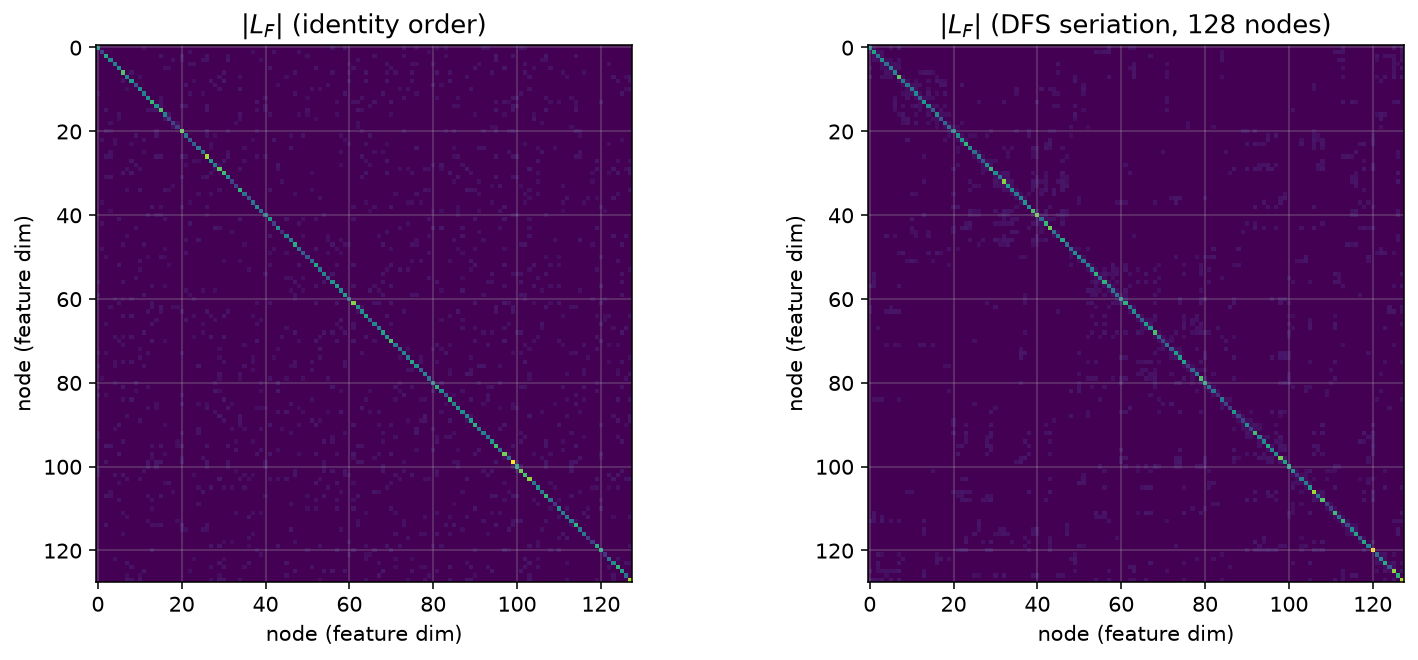

In [5]:
import collections

ser = sequence_by_graph(gl)
so = np.asarray(ser.order)
L = np.abs(np.asarray(gl.to_dense(), dtype=np.float64))
nz_rows, nz_cols = np.nonzero(L)

def mean_edge_bandwidth(perm):
    return float(np.abs(perm[nz_rows] - perm[nz_cols]).mean()) if len(nz_rows) else 0.0

bw_id = mean_edge_bandwidth(np.arange(L.shape[0]))
bw_ser = mean_edge_bandwidth(so)
print(f"nodes={L.shape[0]}  components={ser.components}  "
      f"mean edge bandwidth: identity={bw_id:.2f}  seriated={bw_ser:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].imshow(L, cmap="viridis")
axes[0].set_title(r"$|L_F|$ (identity order)")
axes[1].imshow(L[np.ix_(so, so)], cmap="viridis")
axes[1].set_title(r"$|L_F|$ (DFS seriation, 128 nodes)")
for ax in axes:
    ax.set_xlabel("node (feature dim)"); ax.set_ylabel("node (feature dim)")
fig.savefig(OUT / "fig_03_graph_seriation.png")
plt.show()

sparse wiring: components=42  DFS-blocks=42  bandwidth 32.27 -> 34.11


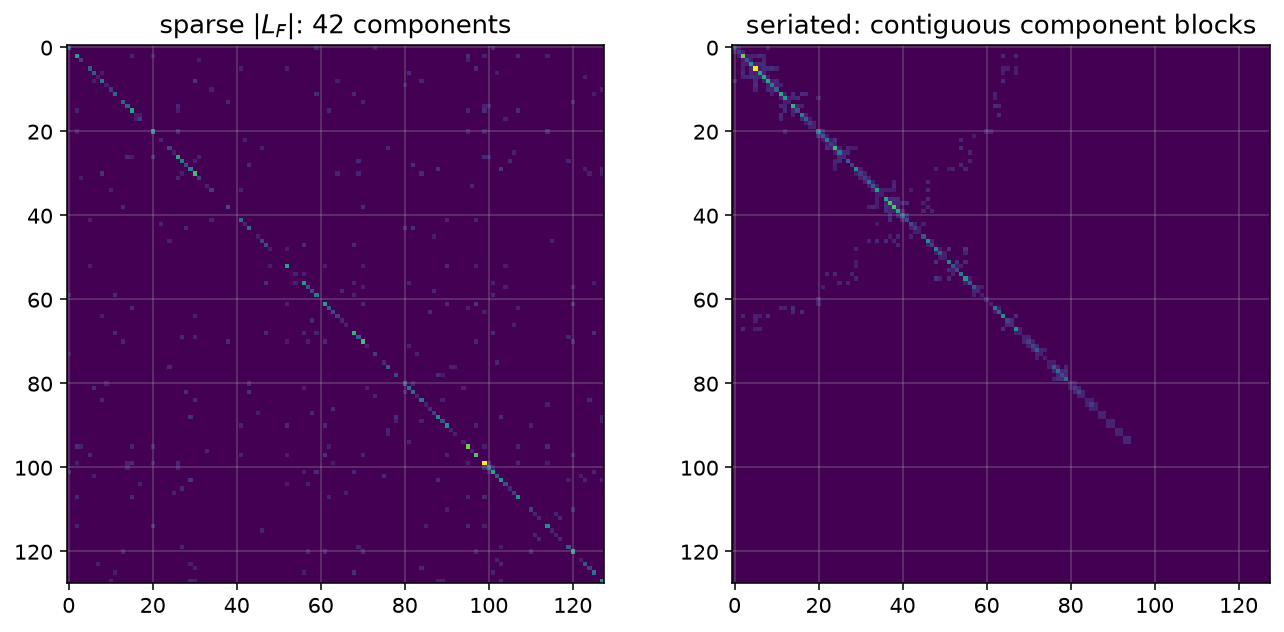

In [6]:
# The real payoff of the seriator shows when L_F fragments: shrink eps/k and the
# dimension graph splits into many components, which the walk lays out as contiguous
# blocks. (Component-per-run contiguity is guaranteed by the DFS design — assert it.)
aspace_s, gl_s = (
    ArrowSpaceBuilder()
    .with_seed(SEED)
    .with_dims_reduction(False, None)
    .build({"eps": 0.25, "k": 3, "topk": 8, "p": 2.0, "sigma": 0.25}, X)
)
ser_s = sequence_by_graph(gl_s)
so_s = np.asarray(ser_s.order)
Ls = np.abs(np.asarray(gl_s.to_dense(), dtype=np.float64))

def mean_edge_bandwidth_S(perm):
    r, c = np.nonzero(Ls)
    return float(np.abs(perm[r] - perm[c]).mean())

adj = collections.defaultdict(set)
rs, cs = np.nonzero(Ls)
for r, c in zip(rs, cs):
    adj[r].add(c); adj[c].add(r)
seen, comp_id = set(), {}
for n0 in range(Ls.shape[0]):
    if n0 in seen:
        continue
    stack = [n0]; seen.add(n0)
    while stack:
        u = stack.pop(); comp_id[u] = n0
        for v in adj[u]:
            if v not in seen:
                seen.add(v); stack.append(v)

runs = [comp_id[so_s[0]]] + [comp_id[so_s[i]] for i in range(1, len(so_s))
                             if comp_id[so_s[i]] != comp_id[so_s[i - 1]]]
print(f"sparse wiring: components={ser_s.components}  DFS-blocks={len(runs)}  "
      f"bandwidth {mean_edge_bandwidth_S(np.arange(Ls.shape[0])):.2f} -> {mean_edge_bandwidth_S(so_s):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4))
axes[0].imshow(Ls, cmap="viridis")
axes[0].set_title(f"sparse $|L_F|$: {ser_s.components} components")
axes[1].imshow(Ls[np.ix_(so_s, so_s)], cmap="viridis")
axes[1].set_title("seriated: contiguous component blocks")
fig.savefig(OUT / "fig_04_multi_component.png")
plt.show()

assert len(runs) == ser_s.components, "each component must occupy one contiguous run"
assert ser_s.components > 10, "the sparse wiring should genuinely fragment the dimension graph"

---\n## 4 · Guardrails

In [7]:
try:
    sequence_by_lambda([0.5])
except ValueError as e:
    print("single score ->", e)

s_list = sequence_by_lambda([0.2, 0.9, 0.5])          # plain lists are accepted
print("list input order:", np.asarray(s_list.order), "positions:", np.asarray(s_list.positions))
assert np.array_equal(np.asarray(s_list.order), [0, 2, 1])

single score -> sequencing requires at least two items, got 1
list input order: [0 2 1] positions: [0.2 0.5 0.9]


---\n## 5 · Summary

In [8]:
summary = pd.DataFrame({
    "quantity": ["lambda curriculum: mean windowed purity",
                 "lambda curriculum: random-order baseline",
                 "sparse-cluster share: first decile",
                 "sparse-cluster share: last decile",
                 "graph seriation: bandwidth (sparse, identity)",
                 "graph seriation: bandwidth (sparse, seriated)",
                 "graph seriation: components (sparse)"],
    "value": [round(float(pur_cur.mean()), 3),
              round(float(pur_rand.mean()), 3),
              round(float(share_sparse[0]), 3),
              round(float(share_sparse[-1]), 3),
              round(mean_edge_bandwidth_S(np.arange(Ls.shape[0])), 3),
              round(mean_edge_bandwidth_S(so_s), 3),
              ser_s.components],
})
summary.to_csv(OUT / "sequencing_summary.csv", index=False)
print(summary.to_string(index=False))

                                     quantity  value
      lambda curriculum: mean windowed purity  0.532
     lambda curriculum: random-order baseline  0.429
           sparse-cluster share: first decile  0.180
            sparse-cluster share: last decile  0.440
graph seriation: bandwidth (sparse, identity) 32.274
graph seriation: bandwidth (sparse, seriated) 34.111
         graph seriation: components (sparse) 42.000


**Reading.**

1. The $\lambda\tau$ curriculum is a real ordering signal on 128-dim embeddings: windowed
   purity beats the random baseline (0.53 vs 0.43) and the decile drift follows the
   sparsity gradient — all unsupervised. The margins here are fixture-dependent; on
   tightly-wired graphs the curriculum is sharper than on sparse wirings.
2. Seriation's contiguity guarantee (one run per component) is what makes it safe for
   batching/visualisation of a fragmented dimension graph; the ~40-way fragmentation at
   `eps=0.25, k=3` is a wiring *finding*, not a failure — the walk handles it
   deterministically. Note DFS preorder gives *contiguity*, not minimum bandwidth: the
   sparse-graph bandwidth can move either way (here 32.3 -> 34.1) — only contiguity is
   asserted.
3. The two sequences live in different namespaces (items vs feature nodes): compare their
   *metrics* (purity, bandwidth, contiguity), never their `order` arrays.

**Version note.** Values in this notebook are pinned to arrowspace 0.28.0: release 0.28
fixed a matrix-layout defect (#167) that changes every stored $\lambda$ and the graph
content behind it — indexes built with $\le$ 0.27.4 must be rebuilt.

**Caveats.** Purity yardsticks use k-means labels from the same data — fine for a
controlled fixture, but on real embeddings prefer label-free window statistics. The
$\tau$-sweep companion (notebook 00) uses this same build; conclusions transfer.